### EDA and Preprocessing Notebook (Part 2)

There are currently 3 datasets available, consisting of 97 data entries. The datasets are complementary to each other, with the datasets being the clinical data, raw FTIR samples from the data and also the cleaned version of the raw FTIR samples from a domain expert.

For this notebook (Part 2), we will be handling the FTIR data only.

We will start by analysing the raw data:

In [28]:
import pandas as pd

df = pd.read_excel('../data/clinical samples_FTIR raw data.xlsx', header=1)

##### Quick Review:

In [29]:
df.head()

,patient code_number of scan,grouping,4000,3999,3998,3997,3996,3995,3994,3993,...,409,408,407,406,405,404,403,402,401,400
0,C001_1,cancerous,-0.0029,-0.0029,-0.0028,-0.0028,-0.0028,-0.0027,-0.0026,-0.0025,...,-0.0086,-0.0086,-0.0088,-0.0092,-0.0088,-0.0080,-0.0053,0.0001,0.0091,0.0211
1,C001_2,cancerous,0.0061,0.0061,0.0061,0.0061,0.0061,0.0061,0.0061,0.0061,...,0.0329,0.0330,0.0319,0.0299,0.0281,0.0272,0.0275,0.0288,0.0305,0.0323
2,C001_3,cancerous,-0.0027,-0.0027,-0.0027,-0.0027,-0.0026,-0.0026,-0.0026,-0.0026,...,0.0287,0.0291,0.0285,0.0273,0.0260,0.0250,0.0246,0.0252,0.0262,0.0271
3,C002_1,cancerous,-0.0046,-0.0046,-0.0046,-0.0046,-0.0046,-0.0046,-0.0045,-0.0045,...,0.0127,0.0129,0.0121,0.0105,0.0087,0.0078,0.0078,0.0085,0.0094,0.0108
4,C002_2,cancerous,0.0065,0.0065,0.0065,0.0065,0.0065,0.0066,0.0066,0.0066,...,0.0335,0.0338,0.0330,0.0314,0.0299,0.0291,0.0291,0.0297,0.0307,0.0324


In [30]:
df.grouping.value_counts()

grouping
non-cancerous    159
cancerous        132
Name: count, dtype: int64

Checking the shape of the data:

In [31]:
print(len(df.columns)) # Number of columns
print(len(df)) # Number of rows

3603
291


Checking for rows with missing values:

In [32]:
missing_rows = df.isna().any(axis=1).sum()
print(missing_rows)

0


To work with the data in hand, we need to refer to the data dictionary provided.

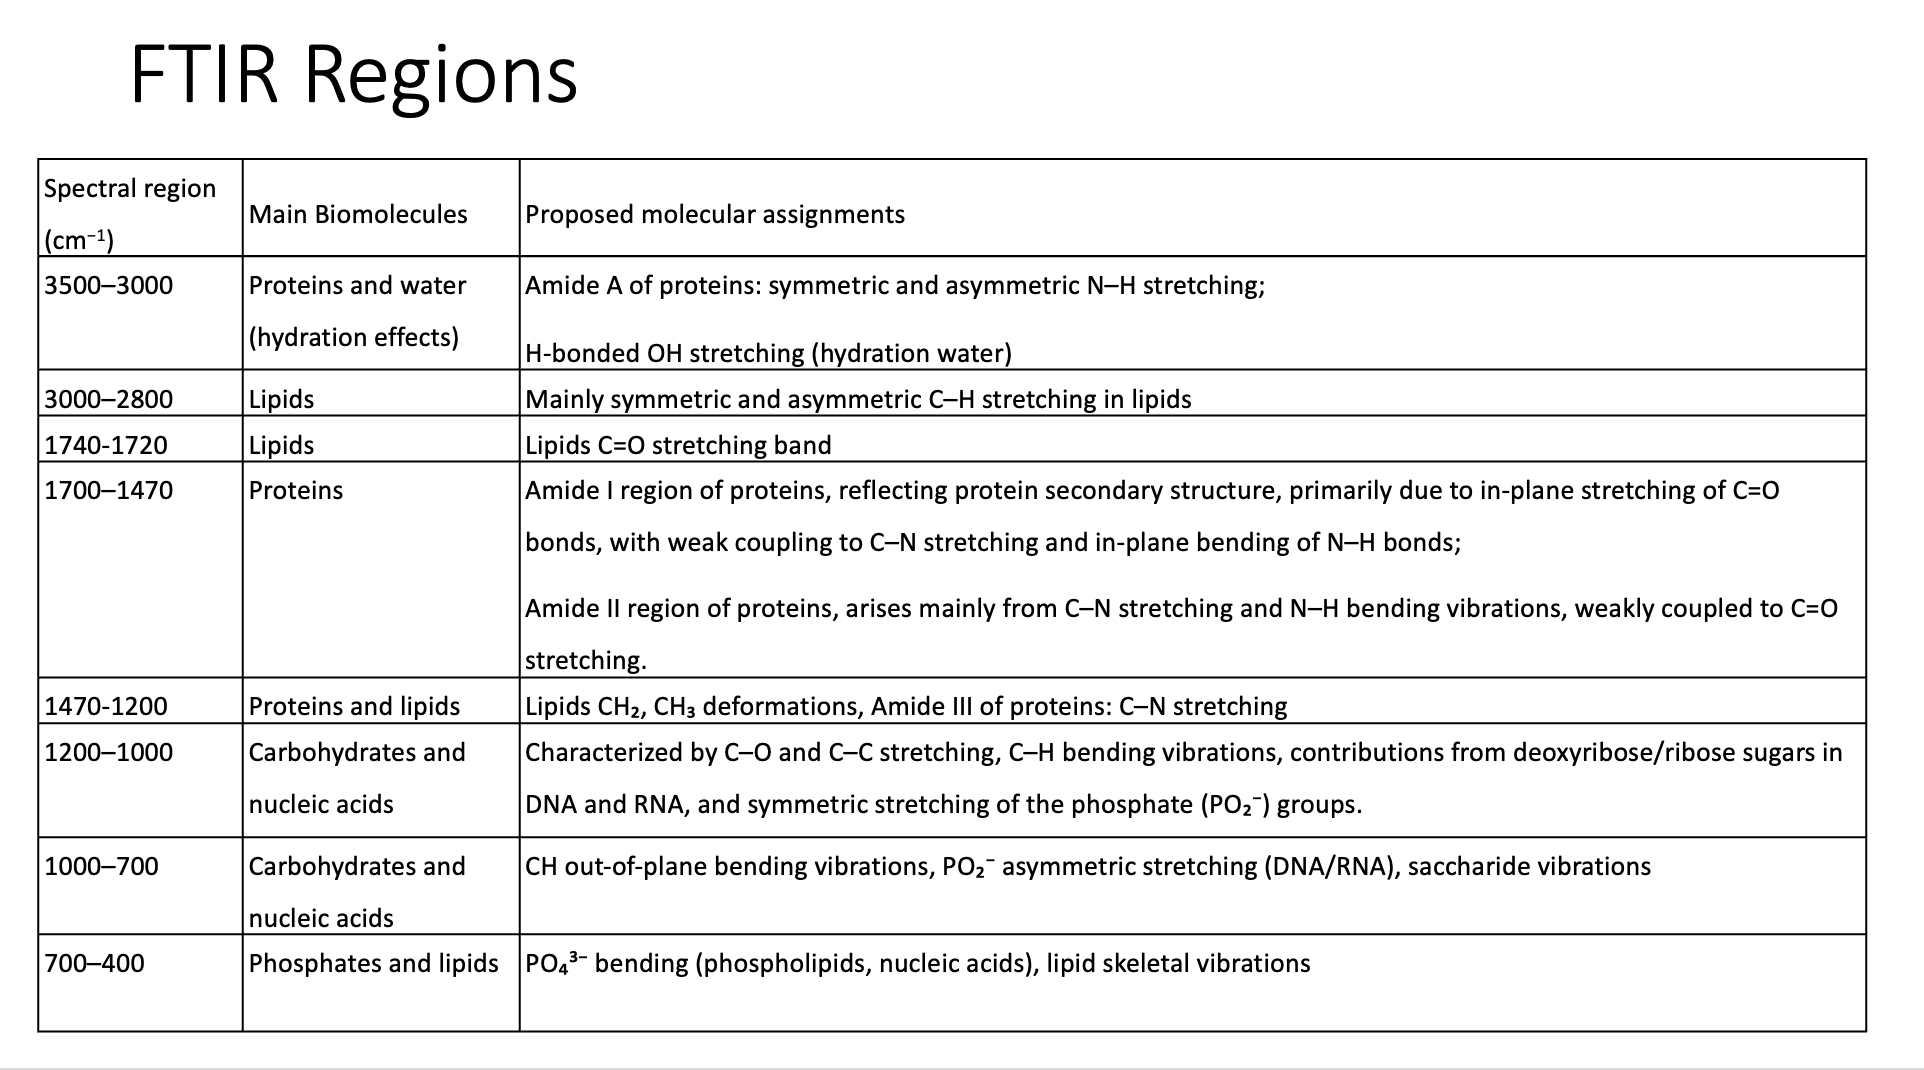

In [33]:
from IPython.display import Image

Image(filename="../data/FTIR_dictionary.png")


Since the spectroscopy dataset is complex, it is useful to partition the columns into their respective spectral sectors and later use them as features. Before doing so, several preprocessing steps are required. First, we apply baseline correction using the Asymmetric Least Squares (ALS) algorithm to remove baseline drift, which is common in spectroscopy data. After obtaining the baseline, we subtract it from each spectrum. Next, we perform L2 normalization (Euclidean norm) to ensure scale invariance across samples. Finally, we apply the Savitzky–Golay filter to compute the second derivative, which smooths the signals while enhancing peaks and reducing noise.

In [34]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

X_raw = df.drop(['grouping','patient code_number of scan'], axis=1).values
y_raw = df['grouping'].map({'non-cancerous':0, 'cancerous':1}).values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=42
)

def baseline_als_cpu(y, lam=1e6, p=0.01, niter=10):
    """CPU-based asymmetric least squares baseline correction"""
    y = np.asarray(y)
    L = len(y)

    # Construct second-order difference matrix
    D = np.zeros((L-2, L))
    for i in range(L-2):
        D[i, i:i+3] = [1, -2, 1]
    D = lam * (D.T @ D)

    w = np.ones(L)
    for _ in range(niter):
        W = np.diag(w)
        Z = np.linalg.solve(W + D, w * y)
        w = p * (y > Z) + (1 - p) * (y < Z)

    return Z

def preprocess_spectra(X):
    """Baseline correction, normalization, derivative"""
    X_proc = []
    for row in tqdm(X, desc="Preprocessing"):
        baseline = baseline_als_cpu(row)
        corrected = row - baseline
        normalized = corrected / np.linalg.norm(corrected)
        deriv = savgol_filter(normalized, window_length=15, polyorder=3, deriv=2)
        X_proc.append(deriv)
    return np.array(X_proc)

We can cache the processed file so that we don't need to run it every time.

In [35]:
import os
import numpy as np

train_file = "../data/X_processed_train.npy"
test_file  = "../data/X_processed_test.npy"

if os.path.exists(train_file) and os.path.exists(test_file):
    print("Processed files found. Loading them...")
    X_train = np.load(train_file)
    X_test  = np.load(test_file)
else:
    print("Processed files not found. Running preprocessing...")
    X_train = preprocess_spectra(X_train_raw)
    X_test  = preprocess_spectra(X_test_raw)
    np.save(train_file, X_train)
    np.save(test_file, X_test)

Processed files found. Loading them...


To facilitate interpretation, the spectral range from 4000 cm⁻¹ to 400 cm⁻¹ was partitioned into predefined regions based on the data dictionary. The wavenumber interval per column was first determined from the total number of data points in each spectrum. Using this interval, a mapping was then created to associate each spectral region with its corresponding column indices.

In [36]:
n_cols = X_train.shape[1]
wn_start = 4000
wn_end = 400
wn_step = (wn_start - wn_end) / (n_cols - 1)

sectors_cm = {
    "3500-3000": (3500, 3000),
    "3000-2800": (3000, 2800),
    "1740-1720": (1740, 1720),
    "1700-1470": (1700, 1470),
    "1470-1200": (1470, 1200),
    "1200-1000": (1200, 1000),
    "1000-700": (1000, 700),
    "700-400": (700, 400)
}

spectral_sectors = {}
for label, (high, low) in sectors_cm.items():
    start_idx = int((wn_start - high) / wn_step)
    end_idx   = int((wn_start - low) / wn_step)
    spectral_sectors[label] = (start_idx, end_idx)

Load the pre-trained LightGBM, XGBoost model along with the PCA model if available:

In [ ]:
import joblib

lgbm_FTIR_file = "../models/lgbm_FTIR.joblib"
xgb_FTIR_file = "../models/lxgb_FTIR.joblib"
lgbm_pca_FTIR_file = "../models/lsector_pca_objects_lgbm_FTIR.joblib"
xgb_pca_FTIR_file = "../models/lsector_pca_objects_xgb_FTIR.joblib"

# Load lgbm
if os.path.exists(lgbm_FTIR_file):
    lgbm_FTIR_model = joblib.load(lgbm_FTIR_file)
    print("Loaded LightGBM model from", lgbm_FTIR_file)
else:
    print(lgbm_FTIR_file, "not found.")

# Load xgb
if os.path.exists(xgb_FTIR_file):
    xgb_FTIR_model = joblib.load(xgb_FTIR_file)
    print("Loaded XGBoost model from", xgb_FTIR_file)
else:
    print(xgb_FTIR_file, "not found.")

# Check and load PCA objects
if os.path.exists(xgb_pca_FTIR_file):
    xgb_pca_object = joblib.load(xgb_pca_FTIR_file)
    print("Loaded XGB's PCA objects from", xgb_pca_FTIR_file)
else:
    print(xgb_pca_FTIR_file, "not found.")

if os.path.exists(lgbm_pca_FTIR_file):
    lgbm_pca_object = joblib.load(lgbm_pca_FTIR_file)
    print("Loaded LGBM's PCA objects from", lgbm_pca_FTIR_file)
else:
    print(lgbm_pca_FTIR_file, "not found.")

../model/lgbm_FTIR.joblib not found.
../model/lxgb_FTIR.joblib not found.
../model/lsector_pca_objects_xgb_FTIR.joblib not found.
../model/lsector_pca_objects_lgbm_FTIR.joblib not found.


Since the data has imbalanced target, we will use S.M.O.T.E to increasing the samples for the minority class (class 1 - cancerous).

In [38]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Original class distribution:", Counter(y_train))

# 'auto' can automatically upsample the minority class to match the majority class sample count
smote = SMOTE(sampling_strategy='auto', random_state=42)

X_train_aug, y_train_aug = smote.fit_resample(X_train, y_train)

print("After SMOTE class distribution:", Counter(y_train_aug))
print("X_train_aug shape:", X_train_aug.shape)

Original class distribution: Counter({np.int64(0): 127, np.int64(1): 105})
After SMOTE class distribution: Counter({np.int64(1): 127, np.int64(0): 127})
X_train_aug shape: (254, 3601)


We will start with LightGBM as our gradient boosting based model for binary classification:

In [39]:
import lightgbm as lgb
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold
from sklearn.decomposition import PCA
import optuna
import numpy as np

def objective(trial):
    sector_features = []
    
    # Sector-wise PCA (capture most valuable variation within each sector)
    # Loop through each sectors (defined through the sector logic above), and decide how much
    # PCA components to keep (1 to 20). Each sector is processed individually to preserve the 
    # main variance specific to that chemical region.
    # PCA can help to reduce the dimensionality of the data, creates uncorrelated feature that captures
    # the most of the sector's information.
    for sector, (start, end) in spectral_sectors.items():
        X_sector = X_train_aug[:, start:end]
        n_comp = trial.suggest_int(f"pca_{sector}", 1, min(20, X_sector.shape[1]))
        pca = PCA(n_components=n_comp)
        X_sector_pca = pca.fit_transform(X_sector)
        sector_features.append(X_sector_pca)

    # The resulting PCA-transformed matrices from all sectors are then concatenated to form the final 
    # features set for training.
    X_final = np.concatenate(sector_features, axis=1)

    # Hyperparamters range to be used for tuning
    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 10, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": 1,
        "seed": 42,
        "verbose": -1
    }

    # LightGBM model with 1000 trees
    model = lgb.LGBMClassifier(**params, n_estimators=1000)

    # Repeat the evaluation on 5-fold cross validation, and repeated 2 times 
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
    
    # Use roc-auc as the metric
    scores = cross_val_score(model, X_final, y_train_aug, cv=cv, n_jobs=-1, scoring="roc_auc")
    return np.mean(scores)

study = optuna.create_study(
    direction="maximize", # Maximize the metric (roc-auc) score
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=50) # 50 trials 

print("Best params:", study.best_trial.params)
print("Best mean CV AUC:", study.best_value)

[I 2026-03-26 12:19:30,824] A new study created in memory with name: no-name-a17ccbbe-65e1-4a32-a5fe-c296917806d2
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted wi

Best params: {'pca_3500-3000': 4, 'pca_3000-2800': 14, 'pca_1740-1720': 1, 'pca_1700-1470': 19, 'pca_1470-1200': 15, 'pca_1200-1000': 19, 'pca_1000-700': 19, 'pca_700-400': 12, 'learning_rate': 0.034376443166151446, 'num_leaves': 86, 'max_depth': 11, 'feature_fraction': 0.6013139731823876, 'bagging_fraction': 0.7578886456629272}
Best mean CV AUC: 0.9375507692307693


At 50 iteration, Optuna found the best parameters for LightGBM to be at 0.925 AUC score.

We then evaluate the model's score on the unseen test set below (20% of the original data):

In [42]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

best_params_lgbm = study.best_trial.params

# Fit PCA objects per sector on training data
pca_objects = {}
sector_features_train = []
sector_features_test  = []

# Use the best PCA component values for each sector found through Optuna
for sector, (start, end) in spectral_sectors.items():
    X_sector_train = X_train_aug[:, start:end]
    n_comp = best_params_lgbm[f"pca_{sector}"]
    pca = PCA(n_components=n_comp)
    X_sector_train_pca = pca.fit_transform(X_sector_train)
    pca_objects[sector] = pca
    sector_features_train.append(X_sector_train_pca)

    # Transform test sector
    X_sector_test = X_test[:, start:end]
    sector_features_test.append(pca.transform(X_sector_test))

# Finally combine the PCA-transformed matrices
X_train_final = np.concatenate(sector_features_train, axis=1)
X_test_final  = np.concatenate(sector_features_test, axis=1)

# Recreate the LightGBM model with the best parameters found
lgbm_FTIR_model = lgb.LGBMClassifier(
    n_estimators=1000,
    max_depth=best_params_lgbm.get("max_depth", -1),
    learning_rate=best_params_lgbm.get("learning_rate", 0.1),
    num_leaves=best_params_lgbm.get("num_leaves", 31),
    subsample=best_params_lgbm.get("bagging_fraction", 1.0),
    colsample_bytree=best_params_lgbm.get("feature_fraction", 1.0),
    random_state=42,
    n_jobs=-1,
    # device='gpu'
)
lgbm_FTIR_model.fit(X_train_final, y_train_aug)

y_pred = lgbm_FTIR_model.predict(X_test_final)
y_prob = lgbm_FTIR_model.predict_proba(X_test_final)[:, 1]

# Get the metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("LightGBM Accuracy:", accuracy)
print("LightGBM AUC:", auc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

[LightGBM] [Info] Number of positive: 127, number of negative: 127
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000516 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8897
[LightGBM] [Info] Number of data points in the train set: 254, number of used features: 103
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


We then save the model for reuse:

In [44]:
import joblib

joblib.dump(lgbm_FTIR_model, "../models/lgbm_FTIR.joblib")
joblib.dump(pca_objects, "../models/sector_pca_objects_lgbm_FTIR.joblib")

['../models/sector_pca_objects_lgbm_FTIR.joblib']

In [45]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold
from sklearn.decomposition import PCA
import optuna
import numpy as np

def objective(trial):
    sector_features = []
    for sector, (start, end) in spectral_sectors.items():
        X_sector = X_train_aug[:, start:end]
        n_comp = trial.suggest_int(f"pca_{sector}", 1, min(20, X_sector.shape[1]))
        pca = PCA(n_components=n_comp)
        X_sector_pca = pca.fit_transform(X_sector)
        sector_features.append(X_sector_pca)

    X_final = np.concatenate(sector_features, axis=1)

    params = {
        "n_estimators": 1000,
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "tree_method": "hist",
        "random_state": 42,
        "use_label_encoder": False,
        "eval_metric": "auc"
    }

    model = XGBClassifier(**params)

    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
    scores = cross_val_score(model, X_final, y_train_aug, cv=cv, n_jobs=-1, scoring="roc_auc")
    return np.mean(scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best params:", study.best_trial.params)
print("Best mean CV AUC:", study.best_value)

best_params_xgb = study.best_trial.params


[I 2026-03-26 13:41:36,329] A new study created in memory with name: no-name-cb257f27-ccc2-4242-8e9f-d51dac95b8c0
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [13:41:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [13:41:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [13:41:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks

Best params: {'pca_3500-3000': 4, 'pca_3000-2800': 16, 'pca_1740-1720': 4, 'pca_1700-1470': 4, 'pca_1470-1200': 20, 'pca_1200-1000': 10, 'pca_1000-700': 5, 'pca_700-400': 8, 'max_depth': 4, 'learning_rate': 0.025097518894802665, 'subsample': 0.6377471691714324, 'colsample_bytree': 0.949962455944471}
Best mean CV AUC: 0.9272861538461539


In [47]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.decomposition import PCA
import numpy as np

# Assuming best_params and spectral_sectors are already defined
# Fit PCA objects per sector on training data
pca_objects = {}
sector_features_train = []
sector_features_test  = []

for sector, (start, end) in spectral_sectors.items():
    X_sector_train = X_train_aug[:, start:end]
    n_comp = best_params_lgbm[f"pca_{sector}"]
    pca = PCA(n_components=n_comp)
    X_sector_train_pca = pca.fit_transform(X_sector_train)
    pca_objects[sector] = pca
    sector_features_train.append(X_sector_train_pca)

    # Transform test sector
    X_sector_test = X_test[:, start:end]
    sector_features_test.append(pca.transform(X_sector_test))

X_train_final = np.concatenate(sector_features_train, axis=1)
X_test_final  = np.concatenate(sector_features_test, axis=1)

# Initialize XGBoost classifier
xgb_FTIR_model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=best_params_xgb.get("max_depth", 6),
    learning_rate=best_params_xgb.get("learning_rate", 0.1),
    subsample=best_params_xgb.get("subsample", 1.0),
    colsample_bytree=best_params_xgb.get("colsample_bytree", 1.0),
    use_label_encoder=False,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
    # tree_method="gpu_hist",
    # predictor="gpu_predictor"
)

# Fit model
xgb_FTIR_model.fit(X_train_final, y_train_aug)

# Predictions
y_pred = xgb_FTIR_model.predict(X_test_final)
y_prob = xgb_FTIR_model.predict_proba(X_test_final)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("XGBoost Accuracy:", accuracy)
print("XGBoost AUC:", auc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [13:43:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8813559322033898
XGBoost AUC: 0.9421296296296295

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.89        32
           1       0.88      0.85      0.87        27

    accuracy                           0.88        59
   macro avg       0.88      0.88      0.88        59
weighted avg       0.88      0.88      0.88        59


Confusion Matrix:
 [[29  3]
 [ 4 23]]


In [48]:
import joblib

joblib.dump(xgb_FTIR_model, "../models/xgb_FTIR.joblib")
joblib.dump(pca_objects, "../models/sector_pca_objects_xgb_FTIR.joblib")

['../models/sector_pca_objects_xgb_FTIR.joblib']

In [51]:
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# Get predicted probabilities for the positive class
lgbm_prob = lgbm_FTIR_model.predict_proba(X_test_final)[:, 1]
xgb_prob  = xgb_FTIR_model.predict_proba(X_test_final)[:, 1]

# Average probabilities
ensemble_prob = (lgbm_prob + xgb_prob) / 2

# Convert to class labels (threshold = 0.3)
ensemble_pred = (ensemble_prob >= 0.3).astype(int)

# --- Metrics ---
accuracy = accuracy_score(y_test, ensemble_pred)
auc = roc_auc_score(y_test, ensemble_prob)

print("Ensemble Accuracy:", accuracy)
print("Ensemble AUC:", auc)
print("\nClassification Report:\n", classification_report(y_test, ensemble_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, ensemble_pred))


Ensemble Accuracy: 0.8813559322033898
Ensemble AUC: 0.9525462962962963

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.88      0.89        32
           1       0.86      0.89      0.87        27

    accuracy                           0.88        59
   macro avg       0.88      0.88      0.88        59
weighted avg       0.88      0.88      0.88        59


Confusion Matrix:
 [[28  4]
 [ 3 24]]


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
